# POTATO LEAF DISEASE DETECTION USING DEEP LEARNING 

<div style="display: flex; justify-content: center; gap: 20px;">
  <img src="potato 1.jpg" alt="potato plant" width="500">
  <img src="potato 2.jpg" alt="potato plant 2" width="500">

# 1. Business Understanding

## 1.1 Project Overview

> Potato is one of the most important food and income-generating crops in Kenya and other developing countries. It plays a key role in ensuring food security and supporting smallholder farmers’ livelihoods. However, potato production is highly affected by fungal diseases, especially Early Blight (Alternaria solani) and Late Blight (Phytophthora infestans). These diseases can lead to significant yield losses if not detected and managed in time.

> Currently, disease detection mostly depends on farmers or agricultural officers visually inspecting the plants. This process is often slow, subjective, and not accessible to farmers in remote areas. To address this challenge, technology can be used to create automated systems that detect these diseases using images of potato leaves.

> This project aims to build a deep learning-based image classification model that can automatically identify whether a potato leaf is Healthy, affected by Early Blight, or affected by Late Blight. The model can later be integrated into a web or mobile application that farmers can use in real time to monitor the health of their crops.

## 1.2 Problem Statement

> Potato production is severely affected by fungal diseases such as Early Blight (Alternaria solani) and Late Blight (Phytophthora infestans). These two diseases can cause yield losses of up to 50% if not detected and managed in time.
Currently, disease diagnosis relies on visual inspection by farmers or extension officers, which is often delayed, subjective, and unavailable in remote areas. This project aims to develop a deep learning image classification model that can automatically detect Early Blight, Late Blight, and Healthy potato leaves from simple photos.


## 1.3 Business Objectives

### 1.3.1 Main Objective

> To develop an image classification model that can automatically detect and classify potato leaf diseases into three categories: Healthy, Early Blight, and Late Blight , using deep learning techniques.

### 1.3.2 Specific Objectives

- To collect, clean, augment, and explore potato leaf image data to ensure balanced and quality inputs for model training.

- To design and train a convolutional neural network (CNN) and apply transfer learning (e.g., MobileNetV2 or ResNet50) for accurate multi-class disease classification.

- To build a Streamlit-based web app for real-time disease detection and provide actionable, localized recommendations for farmers based on model results.

## 1.3.3 Research Questions

- How can potato leaf image data be effectively collected, cleaned and augmented to ensure balanced and high-quality inputs for disease classification?

- Which deep learning approach can best identify and classify potato leaf diseases with high accuracy?

- How can the trained model be deployed through a Streamlit web application to provide real-time disease detection and actionable recommendations for farmers?

## 1.4 Success criteria

- The developed model achieves at least 80–90% accuracy on the validation dataset.

- The Streamlit web app functions correctly and allows users to upload leaf images and receive reliable disease predictions.

- The system provides clear and useful recommendations based on the model’s output.

- The solution demonstrates potential for real-world agricultural use, helping farmers make informed decisions and reduce yield losses.

# 2. Data Understanding

The dataset used in this project comes from [Mendeley Data — “PlantVillage Dataset: Potato Leaf Disease”](https://data.mendeley.com/datasets/tywbtsjrjv/1)

It contains labeled images of potato leaves under three categories:
* Healthy Leaves
* Early Blight
* Late Blight

Data Summary:
- Total images: 7500 original images.
- Classes: 3 (Healthy, Early Blight, Late Blight)
- Format: JPEG
- Resolution: Variable, to be resized to 224×224 for model training
- Image collection: Captured under field and controlled lighting conditions

Count:
- Healthy	 2500	Normal leaves with no visible spots
- Early Blight  2500	Brown circular spots with concentric rings
- Late Blight	 2500	Dark, irregular lesions, often with chlorosis

Dataset Structure:

Potato Leaves Dataset

Potato___Early_blight/

├── 001187a0-57ab-4329-baff-e7246a9ede0b__RS_Early_blight_9178-1.JPG.rf.9dfb0893225d90ab305fb01ac5d3b8f2.jpg

├── 001187a0-57ab-4329-baff-e7246a9ede0b__RS_Early_blight_9178_180ed.JPG.rf.99276b0147b2e8e7db70608cb9bc5.jpg

├── ...


Potato___healthy_aug/

├── aug_0_1003.jpg

├── aug_0_1007.jpg

├── ...


Potato___late_blight/

├── image (1).JPG

├── image (10).JPG

├── ...


## Loading the data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from PIL import Image
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import hashlib
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [4]:

# Define the base directory
base_dir = os.path.join(os.getcwd(), 'Potato leaves dataset')

# Folder paths for each class
early_blight_dir = os.path.join(base_dir, 'Potato___Early_blight')
late_blight_dir = os.path.join(base_dir, 'Potato___Late_blight')
healthy_dir = os.path.join(base_dir, 'Potato___healthy_aug')

# Verify all paths exist
print("Early blight folder:", os.path.exists(early_blight_dir))
print("Late blight folder:", os.path.exists(late_blight_dir))
print("Healthy folder:", os.path.exists(healthy_dir))


Early blight folder: True
Late blight folder: True
Healthy folder: True


In [9]:
# Count images in each class
counts = {
    'early_blight': len(os.listdir(early_blight_dir)),
    'late_blight': len(os.listdir(late_blight_dir)),
    'healthy': len(os.listdir(healthy_dir))
}

print("Image counts per class:", counts)

Image counts per class: {'early_blight': 2500, 'late_blight': 2500, 'healthy': 2500}


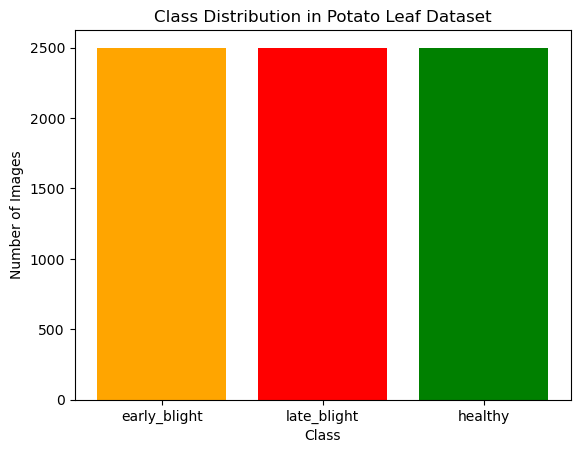

In [10]:
# Visualize counts
plt.bar(counts.keys(), counts.values(), color=['orange', 'red', 'green'])
plt.title("Class Distribution in Potato Leaf Dataset")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.show()

## Preview of images from the 3 classes

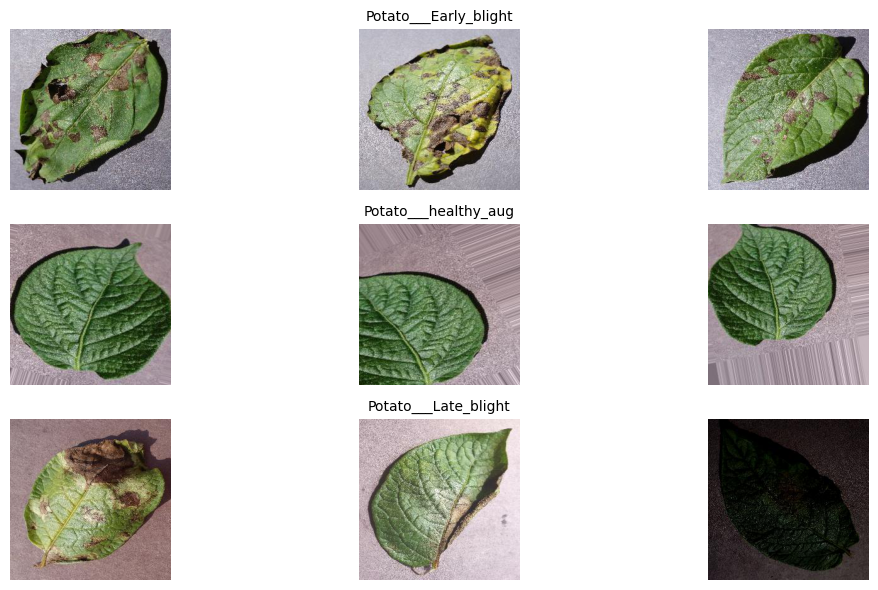

In [16]:
# Preview of random images from the 3 classes

# get class names
classes = [d for d in os.listdir(base_dir) if os.path.isdir(os.path.join(base_dir, d))]

# show random 3 images per class
plt.figure(figsize=(12, 6))

for i, cls in enumerate(classes):
    folder = os.path.join(base_dir, cls)
    img_files = os.listdir(folder)
    sample_files = random.sample(img_files, 3)  # pick 3 random images
    
    for j, file in enumerate(sample_files):
        img_path = os.path.join(folder, file)
        img = mpimg.imread(img_path)
        
        plt.subplot(len(classes), 3, i*3 + j + 1)
        plt.imshow(img)
        plt.axis("off")
        if j == 1:
            plt.title(cls, fontsize=10)

plt.tight_layout()
plt.show()

## Checking for corrupt or unreadable images

In [11]:
# Checking for corrupt or unreadable images
def check_corrupted_images(base_dir, remove=False):
    """
    Checks for unreadable or corrupted images in dataset folders.
    Set remove=True to delete them automatically.
    """
    bad_files = []
    for folder in os.listdir(base_dir):
        folder_path = os.path.join(base_dir, folder)
        if not os.path.isdir(folder_path):
            continue
        for img_name in os.listdir(folder_path):
            img_path = os.path.join(folder_path, img_name)
            try:
                with Image.open(img_path) as img:
                    img.verify()
            except Exception:
                bad_files.append(img_path)
                if remove:
                    os.remove(img_path)
    
    print(f"Found {len(bad_files)} unreadable or corrupted images.")
    if not remove and bad_files:
        print("Use remove=True to delete them.")
    return bad_files

In [14]:
# check for bad images
check_corrupted_images(base_dir)

Found 0 unreadable or corrupted images.
Found 0 unreadable or corrupted images.


[]

## Checking for duplicates

In [17]:
# checking for duplicates

def find_duplicates(data_dir, remove=False):
    """
    Finds duplicate images by comparing their content.
    Set remove=True to automatically delete duplicates.
    """
    hashes = {}
    duplicates = []

    for root, _, files in os.walk(data_dir):
        for file in files:
            img_path = os.path.join(root, file)
            try:
                with Image.open(img_path) as img:
                    img_hash = hashlib.md5(img.tobytes()).hexdigest()
                    if img_hash in hashes:
                        duplicates.append(img_path)
                        if remove:
                            os.remove(img_path)
                    else:
                        hashes[img_hash] = img_path
            except Exception:
                pass

    print(f"Found {len(duplicates)} duplicate images.")
    if not remove and duplicates:
        print("Use remove=True to delete them automatically.")
    elif remove:
        print("Duplicate images deleted successfully.")
    return duplicates

In [18]:
find_duplicates(base_dir, remove=False)

Found 4 duplicate images.
Use remove=True to delete them automatically.


['C:\\Users\\user\\Potato leaves dataset\\Potato___Early_blight\\image (222).JPG',
 'C:\\Users\\user\\Potato leaves dataset\\Potato___Early_blight\\image (359).JPG',
 'C:\\Users\\user\\Potato leaves dataset\\Potato___Early_blight\\image (809).JPG',
 'C:\\Users\\user\\Potato leaves dataset\\Potato___Early_blight\\image (836).JPG']

# 3. Data Preparation

## Removing duplicates

In [19]:
# cleaning of duplicated images in our dataset using the find_duplicates function
find_duplicates(base_dir, remove=True)

Found 4 duplicate images.
Duplicate images deleted successfully.


['C:\\Users\\user\\Potato leaves dataset\\Potato___Early_blight\\image (222).JPG',
 'C:\\Users\\user\\Potato leaves dataset\\Potato___Early_blight\\image (359).JPG',
 'C:\\Users\\user\\Potato leaves dataset\\Potato___Early_blight\\image (809).JPG',
 'C:\\Users\\user\\Potato leaves dataset\\Potato___Early_blight\\image (836).JPG']

We now separate the data into train, test and validation sets.

## Splitting our data into train, validation and test sets

In [ ]:
import os
import shutil
import random


# Define output folders
split_dir = base_dir  # save splits inside the same main folder
train_dir = os.path.join(split_dir, "train")
val_dir = os.path.join(split_dir, "val")
test_dir = os.path.join(split_dir, "test")

# Split ratios
train_ratio = 0.7
val_ratio = 0.15
test_ratio = 0.15

# Create split directories
for folder in [train_dir, val_dir, test_dir]:
    os.makedirs(folder, exist_ok=True)

# Get the list of class folders
classes = [d for d in os.listdir(base_dir) if os.path.isdir(os.path.join(base_dir, d)) and not d in ['train', 'val', 'test']]

for cls in classes:
    cls_folder = os.path.join(base_dir, cls)
    images = os.listdir(cls_folder)
    random.shuffle(images)
    
    total = len(images)
    train_end = int(train_ratio * total)
    val_end = int((train_ratio + val_ratio) * total)
    
    train_files = images[:train_end]
    val_files = images[train_end:val_end]
    test_files = images[val_end:]
    
    # Create subfolders
    for subset, subset_files in zip([train_dir, val_dir, test_dir], [train_files, val_files, test_files]):
        subset_class_dir = os.path.join(subset, cls)
        os.makedirs(subset_class_dir, exist_ok=True)
        for file in subset_files:
            src = os.path.join(cls_folder, file)
            dst = os.path.join(subset_class_dir, file)
            shutil.copy(src, dst)
    
    print(f" {cls}: {len(train_files)} train, {len(val_files)} val, {len(test_files)} test images")




## Data Augmentation

Applying light augmentation during training to improve robustness.

In [3]:
# Applying augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2]
)

# Validation/Test data generator 
test_datagen = ImageDataGenerator(rescale=1./255) 


In [6]:
# Training data generator
train_generator = train_datagen.flow_from_directory(
    os.path.join(base_dir, 'train'),
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=True
)

Found 6840 images belonging to 3 classes.


In [7]:
# Validation data generator
val_generator = test_datagen.flow_from_directory(
    os.path.join(base_dir, 'val'),
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 2102 images belonging to 3 classes.


In [8]:
# Testing data generator
test_generator = test_datagen.flow_from_directory(
    os.path.join(base_dir, 'test'),
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 2094 images belonging to 3 classes.


In [9]:
train_generator.class_indices

{'Potato___Early_blight': 0,
 'Potato___Late_blight': 1,
 'Potato___healthy_aug': 2}

In [10]:
batch = next(train_generator)
images, labels = batch

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Average pixel value:", images.mean())


Image batch shape: (32, 224, 224, 3)
Label batch shape: (32, 3)
Average pixel value: 0.5207957


In each batch we have 32 images having a height and width of 224 pixels and 3 colour channels (Red, Green, Blue).

# 4. Modeling

## Deep Learning with CNN

In [11]:
# CNN model
import tensorflow as tf


model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    # output layer
    tf.keras.layers.Dense(3, activation='softmax')
])

C:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


| Layer               | Purpose                                             |
| ------------------- | --------------------------------------------------- |
| `Conv2D(32)`        | Detects simple features (edges, textures)           |
| `MaxPooling2D(2,2)` | Reduces image size to focus on main features        |
| `Conv2D(64)`        | Learns more complex patterns (disease spots, veins) |
| `MaxPooling2D(2,2)` | Further compresses spatial information              |
| `Flatten()`         | Converts 2D feature maps into a 1D vector           |
| `Dense(128, relu)`  | Learns complex relationships                        |
| `Dropout(0.3)`      | Reduces overfitting                                 |
| `Dense(3, softmax)` | Outputs probabilities for each disease class        |


In [13]:
# compiling the model
model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss=tf.keras.losses.categorical_crossentropy,
    metrics=['accuracy'])

In [14]:
# training the model
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15
)

C:\Users\user\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
214/214 ━━━━━━━━━━━━━━━━━━━━ 332s 2s/step - accuracy: 0.8254 - loss: 0.4715 - val_accuracy: 0.9672 - val_loss: 0.0799
Epoch 2/15
214/214 ━━━━━━━━━━━━━━━━━━━━ 217s 1s/step - accuracy: 0.9461 - loss: 0.1488 - val_accuracy: 0.9729 - val_loss: 0.0627
Epoch 3/15
214/214 ━━━━━━━━━━━━━━━━━━━━ 231s 1s/step - accuracy: 0.9480 - loss: 0.1381 - val_accuracy: 0.9791 - val_loss: 0.0659
Epoch 4/15
214/214 ━━━━━━━━━━━━━━━━━━━━ 214s 998ms/step - accuracy: 0.9575 - loss: 0.1078 - val_accuracy: 0.9805 - val_loss: 0.0520
Epoch 5/15
214/214 ━━━━━━━━━━━━━━━━━━━━ 221s 1s/step - accuracy: 0.9595 - loss: 0.1075 - val_accuracy: 0.9891 - val_loss: 0.0308
Epoch 6/15
214/214 ━━━━━━━━━━━━━━━━━━━━ 233s 1s/step - accuracy: 0.9610 - loss: 0.1084 - val_accuracy: 0.9853 - val_loss: 0.0479
Epoch 7/15
214/214 ━━━━━━━━━━━━━━━━━━━━ 230s 1s/step - accuracy: 0.9610 - loss: 0.1054 - val_accuracy: 0.9805 - val_loss: 0.0613
Epoch 8/15
214/214 ━━━━━━━━━━━━━━━━━━━━ 221s 1s/step - accuracy: 0.9680 - loss: 0.0891 - val_a

In [15]:
import matplotlib.pyplot as plt

# Extract data from the training history
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc) + 1)

# Plot Training & Validation Accuracy
plt.figure(figsize=(8, 5))
plt.plot(epochs, acc, label='Training Accuracy')
plt.plot(epochs, val_acc, label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Plot Training & Validation Loss
plt.figure(figsize=(8, 5))
plt.plot(epochs, loss, label='Training Loss')
plt.plot(epochs, val_loss, label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


NameError: name 'history' is not defined

C:\Users\user\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


66/66 ━━━━━━━━━━━━━━━━━━━━ 74s 1s/step


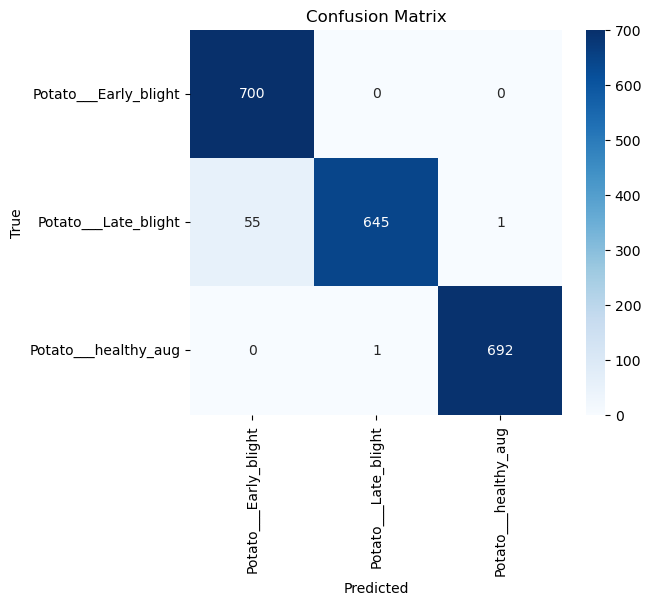

In [16]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Get true and predicted labels
Y_pred = model.predict(test_generator)
y_pred = np.argmax(Y_pred, axis=1)
y_true = test_generator.classes

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
class_labels = list(test_generator.class_indices.keys())

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [17]:
# Classification Report
print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_labels))

Classification Report:

                       precision    recall  f1-score   support

Potato___Early_blight       0.93      1.00      0.96       700
 Potato___Late_blight       1.00      0.92      0.96       701
 Potato___healthy_aug       1.00      1.00      1.00       693

             accuracy                           0.97      2094
            macro avg       0.97      0.97      0.97      2094
         weighted avg       0.97      0.97      0.97      2094

